<a href="https://colab.research.google.com/github/RekhaThota22/Fashion-MNIST-FCNN/blob/main/Fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing necessary libraries:
**Why**: Python have many inbuilt libraries that help in our model loading,training and testing.

In [76]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers,models,callbacks
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential

# Loading the data :

In [ ]:
(train_images,train_labels),(test_images,test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Visualizing the data :
**Why** : By visualizing the data we will be able to understand what type of data we are dealing with.

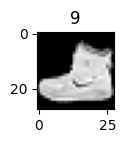

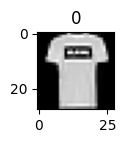

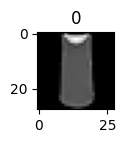

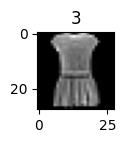

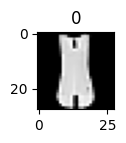

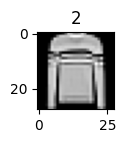

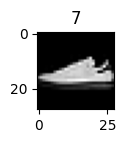

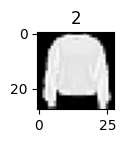

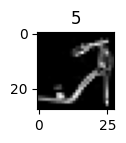

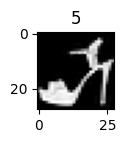

In [ ]:
for i in range(10):
  plt.figure(figsize=(1,1))
  plt.imshow(train_images[i],cmap = 'gray')
  plt.title(train_labels[i])
  plt.show()

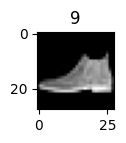

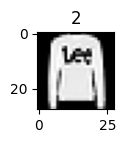

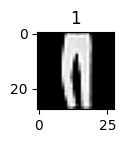

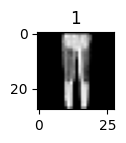

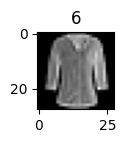

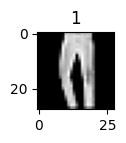

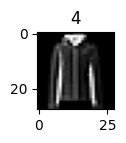

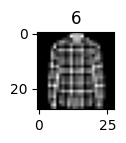

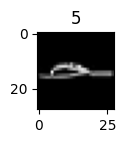

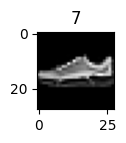

In [ ]:
for i in range(10):
  plt.figure(figsize=(1,1))
  plt.imshow(test_images[i],cmap = 'gray')
  plt.title(test_labels[i])
  plt.show()

In [ ]:
# Normalize the Images
train_images = train_images.astype('float32')/255
test_images  = test_images.astype('float32')/255

In [ ]:
#Converting the categorical labels into a one-hot encoded format
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# Building the model architechture:

In [74]:

def create_model():
  model = models.Sequential([

      # Input layer
      layers.Input(shape = (28,28)),
      layers.Flatten(),

      # Hidden layers
      layers.Dense(128,activation = 'relu'),
      layers.Dense(64,activation = 'relu'),

      #Regularization
      layers.Dropout(0.5),

      #Outout layer
      layers.Dense(10,activation='softmax')

  ])
  return model

In [100]:
model = create_model()
model.compile(optimizer ='sgd',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [101]:
early_stopping = callbacks.EarlyStopping(patience = 3,restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(patience = 2)

In [102]:
history = model.fit(train_images,
                    train_labels,
                    epochs = 15,
                    callbacks = [early_stopping,reduce_lr],
                    validation_data = (test_images,test_labels)
                    )

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6830 - loss: 0.9442 - val_accuracy: 0.7967 - val_loss: 0.5798 - learning_rate: 0.0100
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7896 - loss: 0.6206 - val_accuracy: 0.8247 - val_loss: 0.4985 - learning_rate: 0.0100
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8142 - loss: 0.5523 - val_accuracy: 0.8252 - val_loss: 0.4767 - learning_rate: 0.0100
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8233 - loss: 0.5156 - val_accuracy: 0.8355 - val_loss: 0.4576 - learning_rate: 0.0100
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8327 - loss: 0.4902 - val_accuracy: 0.8424 - val_loss: 0.4350 - learning_rate: 0.0100
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8361 - loss: 0.4763 - val_accuracy: 0.8451 - val_loss: 0.4255 - learning_rate: 0.0100
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8423 - l

# Evaluating the model’s performance using both training and validation datasets.


In [103]:
Training_loss,Training_Accuracy = model.evaluate(train_images, train_labels)
Validation_loss,Validation_Accuracy = model.evaluate(test_images, test_labels)
print(f'Training Accuracy: {Training_Accuracy}')
print(f'Validation Accuracy: {Validation_Accuracy}')
print(f'Training Loss: {Training_loss}')
print(f'Validation Loss: {Validation_loss}')

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8799 - loss: 0.3259
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8614 - loss: 0.3776
Training Accuracy: 0.8799166679382324
Validation Accuracy: 0.8614000082015991
Training Loss: 0.3258844316005707
Validation Loss: 0.37764236330986023


# Visualizing the Validation loss vs Accuracy

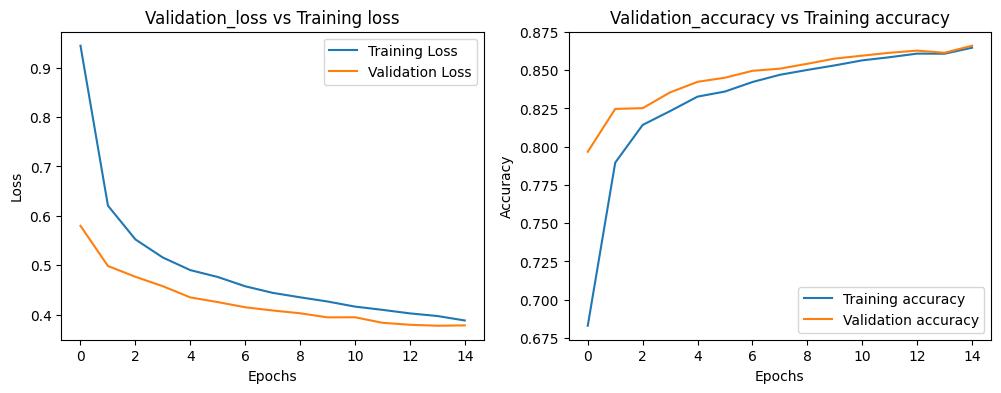

In [104]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
# Loss Plot
plt.plot(history.history['loss'],label = 'Training Loss')
plt.plot(history.history['val_loss'],label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation_loss vs Training loss')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label = 'Training accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation_accuracy vs Training accuracy')
plt.legend()
plt.show()